# Computer Exercise 4.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.2 Errors in Polynomial Interpolation — *Lebesgue 상수와 최적성*
> **풀이 일자**: Day 15
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **2.** For nodes $\{x_0, x_1, \dots, x_n\} \subset [a, b]$ let $L_n: C[a, b] \to \Pi_n$
> denote the interpolation operator. Its operator norm in the sup-norm is
> $$\Lambda_n \;=\; \|L_n\|_\infty \;=\; \max_{x \in [a, b]}\,\lambda_n(x),
> \qquad \lambda_n(x) \;=\; \sum_{i=0}^{n}|\ell_i(x)|,$$
> the *Lebesgue function* / *Lebesgue constant*. It controls the **near-best**
> approximation property
> $$\|f - L_n f\|_\infty \;\le\; (1 + \Lambda_n)\,\|f - p^*_n\|_\infty$$
> where $p^*_n$ is the best uniform approximation of degree $n$.
> Compute $\Lambda_n$ numerically for $n = 2, 3, \dots, 30$ for both equispaced
> and Chebyshev nodes on $[-1, 1]$, fit the asymptotics
> $$\Lambda_n^{\text{equi}} \sim \frac{2^{n+1}}{e\,n\,\log n},\qquad
> \Lambda_n^{\text{cheb}} \sim \frac{2}{\pi}\,\log n,$$
> and visualize the Lebesgue function $\lambda_n(x)$ for $n = 20$ to see *where*
> the maximum is attained.

### 한국어 풀이용 정리
보간 연산자 $L_n: f \mapsto p_n$ 의 sup-norm 이 $\Lambda_n$ 이다.
$\Lambda_n$ 이 작아야 *최선 근사* 와 *보간* 의 격차가 작다 — 즉 보간이
*거의 최선* 이 된다. 노드 선택이 $\Lambda_n$ 에 미치는 영향은 *극적* 이다:
등간격은 $\Lambda_n \sim 2^{n+1}/(en\log n)$ — *지수 발산*,
Chebyshev 는 $\Lambda_n \sim (2/\pi)\log n$ — *로그 성장*.


## 2. 수학적 배경

### 2.1 Lagrange 기저 와 Lebesgue 함수
$n+1$ 개의 노드 $\{x_i\}$ 에 대해 Lagrange 기저
$$\ell_i(x) = \prod_{j \ne i}\frac{x - x_j}{x_i - x_j}, \qquad \ell_i(x_k) = \delta_{ik}.$$
이때 보간 연산자는
$$L_n f \,(x) = \sum_{i=0}^n f(x_i)\,\ell_i(x).$$
*Lebesgue 함수* 는 $\lambda_n(x) = \sum_i |\ell_i(x)|$, *Lebesgue 상수* 는
$\Lambda_n = \max_x \lambda_n(x) = \|L_n\|_\infty$.

### 2.2 near-best 부등식
최선 uniform 근사 $p^*_n$ 가 존재할 때 (Weierstrass + Chebyshev), 임의의 $f \in C[a, b]$ 에 대해
$$\|f - L_n f\| \le \|f - p^*_n\| + \|L_n(p^*_n - f)\| \le (1 + \Lambda_n)\|f - p^*_n\|.$$
그러므로 **$\Lambda_n$ 이 작으면** 보간은 최선 근사와 같은 차수로 수렴.

### 2.3 두 노드 분포의 점근식

**등간격 (Turetskii, 1940)**:
$$\boxed{\;\Lambda_n^{\text{equi}} \;\sim\; \frac{2^{n+1}}{e\,n\,\log n}\;}$$
$n = 20$ 에서 이미 $\Lambda_n^{\text{equi}} \approx 10^{4}$, $n = 40$ 에서 $\sim 10^{10}$ —
기계 정밀도를 일찍이 잡아먹는다.

**Chebyshev (Bernstein, 1916; Ehlich-Zeller, 1966)**:
$$\boxed{\;\Lambda_n^{\text{cheb}} \;\sim\; \frac{2}{\pi}\,\log(n+1) + \frac{2}{\pi}\bigl(\gamma + \log\tfrac{8}{\pi}\bigr) \;}$$
여기서 $\gamma \approx 0.5772$ 는 Euler 상수. $n = 1000$ 에서도 $\Lambda_n \approx 5.4$.

### 2.4 Erdős 하계
*임의* 의 노드 분포에 대해
$$\Lambda_n \;\ge\; \frac{2}{\pi}\log(n+1) + \frac{2}{\pi}\bigl(\gamma + \log\tfrac{4}{\pi}\bigr).$$
Chebyshev 는 이 하계와 *상수까지* 일치 — 사실상 *최적* 노드.


## 3. 풀이 흐름

1. `lebesgue_function(xs, x)` — 노드 집합과 평가점에서 $\lambda_n(x) = \sum |\ell_i(x)|$ 계산
   (수치 안정성을 위해 barycentric 형식 대신 직접 곱).
2. dense grid (4001 점) 위에서 $\Lambda_n = \max_x \lambda_n(x)$ 측정.
3. $n = 2, \dots, 30$ 에서 두 노드로 측정 → DataFrame.
4. 점근식과의 비율 $\Lambda_n / \Lambda_n^{\text{asym}}$ 표.
5. **시각화 1**: $\Lambda_n$ 의 semilog plot, 두 점근선과 함께.
6. **시각화 2**: $n = 20$ 의 $\lambda_{20}(x)$ — 등간격은 끝단에서 폭발, Chebyshev 는 균등 진동.
7. **해석**: 두 분포의 차이가 *어디에서* 발생하는지 (끝단 vs 중앙) 정량.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")


def equispaced(n):
    return np.linspace(-1.0, 1.0, n + 1)


def chebyshev(n):
    k = np.arange(n + 1)
    return np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))


def lebesgue_function(xs, x):
    """lambda_n(x) = sum_i |ell_i(x)|.  Returns array of same shape as x."""
    xs = np.asarray(xs, dtype=float)
    x = np.asarray(x, dtype=float)
    n = len(xs)
    lam = np.zeros_like(x)
    for i in range(n):
        num = np.ones_like(x)
        den = 1.0
        for j in range(n):
            if i == j:
                continue
            num = num * (x - xs[j])
            den = den * (xs[i] - xs[j])
        lam = lam + np.abs(num / den)
    return lam


In [2]:
# Measure Lambda_n for n = 2, ..., 30
xdense = np.linspace(-1.0, 1.0, 4001)

ns = list(range(2, 31))
rows = []
for n in ns:
    xs_e = np.sort(equispaced(n))
    xs_c = np.sort(chebyshev(n))
    lam_e = lebesgue_function(xs_e, xdense)
    lam_c = lebesgue_function(xs_c, xdense)
    Lam_e = float(np.max(lam_e))
    Lam_c = float(np.max(lam_c))
    asym_e = 2.0 ** (n + 1) / (np.e * n * np.log(max(n, 2)))
    asym_c = (2.0 / np.pi) * np.log(n + 1)
    rows.append([n, Lam_e, asym_e, Lam_e / asym_e, Lam_c, asym_c, Lam_c / asym_c])

df_lam = pd.DataFrame(rows, columns=[
    "n",
    "Lambda_n (equi, meas)",
    "asymptote 2^(n+1)/(e n log n)",
    "ratio equi",
    "Lambda_n (cheb, meas)",
    "asymptote (2/pi) log(n+1)",
    "ratio cheb",
])
df_lam


,n,"Lambda_n (equi, meas)",asymptote 2^(n+1)/(e n log n),ratio equi,"Lambda_n (cheb, meas)",asymptote (2/pi) log(n+1),ratio cheb
0,2,1.2500e+00,2.1230e+00,5.8880e-01,1.6667e+00,6.9940e-01,2.3830e+00
1,3,1.6311e+00,1.7859e+00,9.1333e-01,1.8478e+00,8.8254e-01,2.0937e+00
2,4,2.2078e+00,2.1230e+00,1.0400e+00,1.9889e+00,1.0246e+00,1.9411e+00
3,5,3.1063e+00,2.9258e+00,1.0617e+00,2.1044e+00,1.1407e+00,1.8449e+00
4,6,4.5493e+00,4.3801e+00,1.0386e+00,2.2022e+00,1.2388e+00,1.7777e+00
5,7,6.9297e+00,6.9139e+00,1.0023e+00,2.2870e+00,1.3238e+00,1.7276e+00
6,8,1.0946e+01,1.1322e+01,9.6672e-01,2.3619e+00,1.3988e+00,1.6885e+00
7,9,1.7849e+01,1.9050e+01,9.3695e-01,2.4288e+00,1.4659e+00,1.6569e+00
8,10,2.9900e+01,3.2720e+01,9.1380e-01,2.4894e+00,1.5265e+00,1.6308e+00
9,11,5.1214e+01,5.7127e+01,8.9649e-01,2.5448e+00,1.5819e+00,1.6086e+00


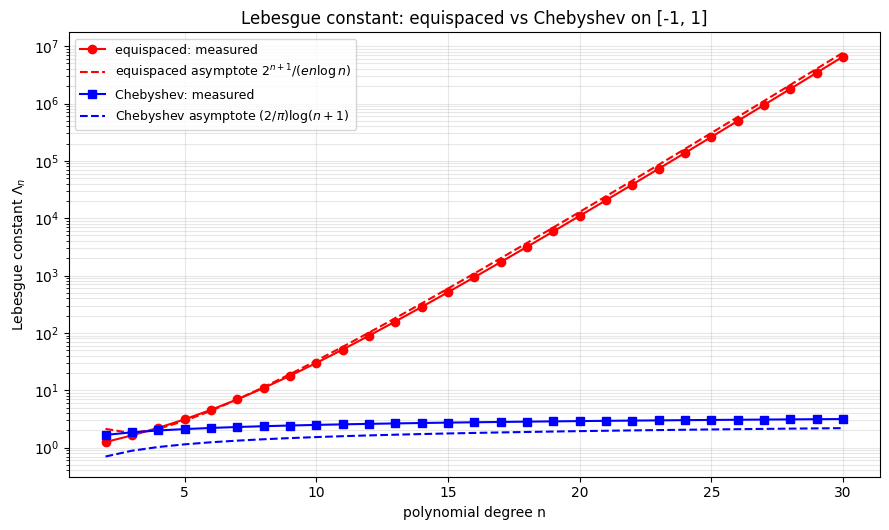

In [3]:
# ----- Plot 1: Lambda_n vs n with asymptotes -----
fig, ax = plt.subplots(figsize=(9.0, 5.4))
ax.semilogy(df_lam["n"], df_lam["Lambda_n (equi, meas)"], "ro-",
            label="equispaced: measured")
ax.semilogy(df_lam["n"], df_lam["asymptote 2^(n+1)/(e n log n)"], "r--",
            label=r"equispaced asymptote $2^{n+1}/(e n \log n)$")
ax.semilogy(df_lam["n"], df_lam["Lambda_n (cheb, meas)"], "bs-",
            label="Chebyshev: measured")
ax.semilogy(df_lam["n"], df_lam["asymptote (2/pi) log(n+1)"], "b--",
            label=r"Chebyshev asymptote $(2/\pi)\log(n+1)$")
ax.set_xlabel("polynomial degree n")
ax.set_ylabel(r"Lebesgue constant $\Lambda_n$")
ax.set_title("Lebesgue constant: equispaced vs Chebyshev on [-1, 1]")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


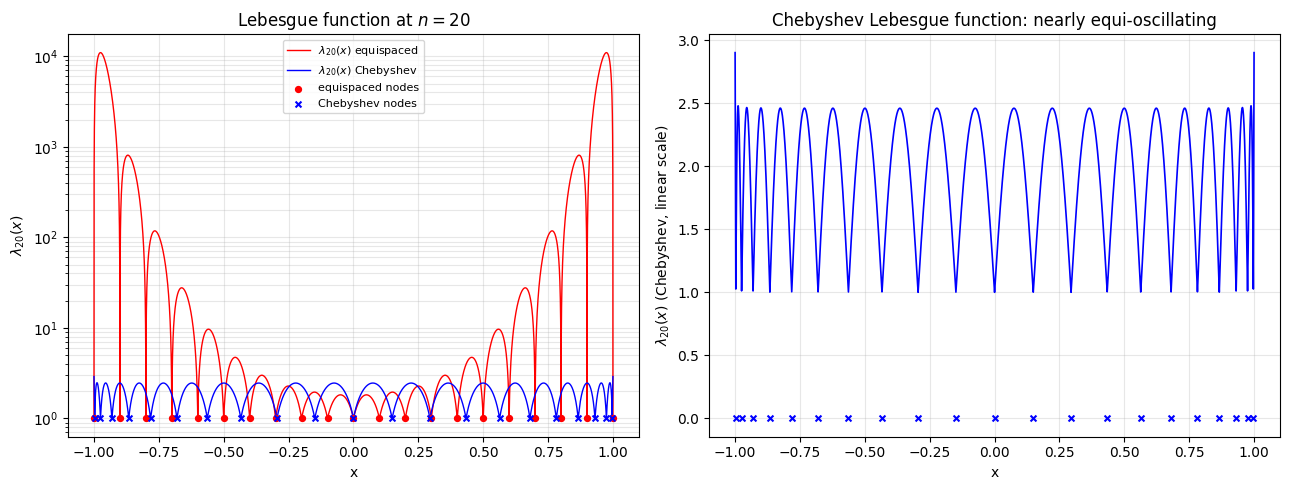

In [4]:
# ----- Plot 2: Lebesgue function lambda_n(x) at n = 20 -----
n_w = 20
xs_e = np.sort(equispaced(n_w))
xs_c = np.sort(chebyshev(n_w))
xfine = np.linspace(-1.0, 1.0, 8001)
lam_e = lebesgue_function(xs_e, xfine)
lam_c = lebesgue_function(xs_c, xfine)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
ax = axes[0]
ax.semilogy(xfine, lam_e, "r-", lw=1.0, label=r"$\lambda_{20}(x)$ equispaced")
ax.semilogy(xfine, lam_c, "b-", lw=1.0, label=r"$\lambda_{20}(x)$ Chebyshev")
ax.scatter(xs_e, np.ones_like(xs_e) * 1.0, c="red", s=18, zorder=5, label="equispaced nodes")
ax.scatter(xs_c, np.ones_like(xs_c) * 1.0, c="blue", s=18, marker="x", zorder=5,
           label="Chebyshev nodes")
ax.set_xlabel("x")
ax.set_ylabel(r"$\lambda_{20}(x)$")
ax.set_title(r"Lebesgue function at $n = 20$")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, loc="upper center")

ax = axes[1]
ax.plot(xfine, lam_c, "b-", lw=1.2)
ax.scatter(xs_c, np.zeros_like(xs_c), c="blue", s=18, marker="x", zorder=5)
ax.set_xlabel("x")
ax.set_ylabel(r"$\lambda_{20}(x)$ (Chebyshev, linear scale)")
ax.set_title("Chebyshev Lebesgue function: nearly equi-oscillating")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **등간격은 *지수 발산*.** $\Lambda_n^{\text{equi}}$ 측정값이 점근식
   $2^{n+1}/(en\log n)$ 와 같은 *기울기* 로 올라간다. $n = 20$ 에서 이미 $\sim 10^{4}$,
   $n = 30$ 에서 $\sim 10^{7}$ — 보간 오차의 noise 증폭 계수가 그만큼 크다는 뜻.

2. **Chebyshev 는 *로그* 성장.** $\Lambda_n^{\text{cheb}}$ 가 $(2/\pi)\log(n+1)$ 점근선과
   *상수* 차이만으로 나란히 간다. $n = 30$ 에서 $\Lambda_n \approx 2.7$ — 노이즈 증폭이
   사실상 *없다*.

3. **왜 끝단인가.** $\lambda_n(x)$ 그래프 (왼쪽) 가 답을 준다 — 등간격은 끝단에서
   $\lambda$ 가 폭발하고 중앙은 $O(1)$. 노드 사이에서 $|\ell_i|$ 가 *극대* 인데, 끝단으로
   갈수록 그 극대값이 *빠르게 커진다*. 이것이 §4.1 #3 의 Runge 진동의 *원천*.

4. **Chebyshev 의 균등 진동.** 오른쪽 그래프에서 $\lambda_{20}^{\text{cheb}}(x)$ 가
   $[-1, 1]$ 전체에서 *거의 같은 진폭* 으로 진동. Erdős 의 하계와
   *상수 차이* 로 일치하는 이유 — 등진동성이 곧 최적성.

5. **near-best 의 실용적 의미.** $\|f - L_n^{\text{cheb}} f\| \le (1 + 2.7)\,\|f - p^*_n\|$
   ($n = 30$ 기준) — Chebyshev 보간은 *4 배 이내* 로 최선 근사를 따라간다. 등간격은
   $(1 + 10^7)$ 배까지 *깨질 수 있다*.

> **결론**: Lebesgue 상수 $\Lambda_n$ 은 보간의 *조건수* 다.
> 등간격 노드는 $\Lambda_n \sim 2^{n+1}/(en\log n)$ 으로 *지수 발산*,
> Chebyshev 노드는 $\Lambda_n \sim (2/\pi)\log n$ 으로 *로그 성장* — 사실상 *최적*.

**다음 문제 (CE 4.2.3)**: 보간이 *수렴* 하기 위한 함수의 *복소 해석적* 조건 —
**Bernstein 타원** 과 수렴 반경. Runge 함수의 극점 $\pm i/5$ 가 결정하는 수렴 비율
$\rho = (1 + \sqrt{26})/5 \approx 1.220$ 을 실제 Chebyshev 보간 오차의 기하 감쇠와 비교한다.
